# Quantitative finance: a walk-forward backtest grid

Backtesting has two problems that lineage is unusually well suited to.

The first is **multiple testing**. You try a hundred parameter combinations,
the best one shows a Sharpe of 1.8, and you report it. But the best of a
hundred random strategies also shows a good Sharpe, and unless you know how
many you tried, you cannot tell the two apart. Almost nobody can say
afterwards how many they tried. A store that recorded every trial can.

The second is **contamination**. A bug in one feature silently invalidates
every result computed downstream of it. Without recorded lineage, finding
which results are affected means remembering what you ran and when.

This notebook builds a walk-forward grid, plants a look-ahead bug, detects it,
traces exactly what it contaminated, destroys those results, and reruns. The
graph is a lattice: parameter configurations across time folds.

```
market_data --> feature_set --> backtest (6 configs x 4 folds) --> selection
                                                                      |
                                                         validation <-+
                                                              |
                                                       risk_report
```

## 1. Setup

In [1]:
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import ancestree

WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-quant-"))
rng = np.random.default_rng(31415)

N_ASSETS = 8
N_DAYS = 2600  # about ten years of trading days
TRADING_DAYS = 252
COST_BPS = 5.0  # round-trip transaction cost in basis points

## 2. A market with regimes

Synthetic daily prices for eight assets. Each asset carries a slowly drifting
expected return, so there is genuine trend for a trend-following rule to find,
plus a common market factor and idiosyncratic noise.

Two thirds of the way through, the drift becomes both weaker and far less
persistent. That regime change is the reason walk-forward evaluation exists: a
strategy fitted across the whole history quietly learns a world that stopped
existing.

In [2]:
dates = pd.bdate_range("2015-01-01", periods=N_DAYS)
regime_change = int(N_DAYS * 0.66)

market = rng.normal(0.0002, 0.009, N_DAYS)
returns = np.zeros((N_DAYS, N_ASSETS))
drift = np.zeros(N_ASSETS)

for day in range(N_DAYS):
    # Persistent drift early; weak and fast-decaying after the regime change.
    persistence, shock = (0.96, 0.0006) if day < regime_change else (0.82, 0.00018)
    drift = persistence * drift + rng.normal(0, shock, N_ASSETS)
    beta = rng.uniform(0.7, 1.2, N_ASSETS)
    returns[day] = beta * market[day] + drift + rng.normal(0, 0.013, N_ASSETS)

prices = 100 * np.exp(np.cumsum(returns, axis=0))
panel = pd.DataFrame(
    prices, index=dates, columns=[f"ASSET_{i:02d}" for i in range(N_ASSETS)]
)
print(panel.iloc[:3, :4].round(2).to_string())
print(
    f"\n{N_DAYS} days, {N_ASSETS} assets, regime change at {dates[regime_change].date()}"
)

            ASSET_00  ASSET_01  ASSET_02  ASSET_03
2015-01-01     98.51     98.28    101.40    100.77
2015-01-02     97.31     97.78    103.32     98.41
2015-01-05     94.83     95.98    104.06     97.34

2600 days, 8 assets, regime change at 2021-07-30


## 3. A store built for an audit

Two policy choices worth being explicit about.

`reuse_identical=False`. Everywhere else the default (collapsing an identical rerun
onto the existing node) is what you want. Here it is not. If a backtest is
rerun and produces byte-identical output, that is still a *separate
execution*, at a separate time, by a separate person, against a possibly
different commit. An audit trail that silently merges two runs into one is
not an audit trail.

`chunk=True` is the default and is left on, though this store will not
benefit much: the artifacts are small equity curves rather than large arrays.
Section 12 comes back to that honestly.

In [3]:
RULES = {
    "market_data": [None],
    "feature_set": ["market_data"],
    "backtest": ["feature_set"],
    "selection": ["backtest"],
    "validation": ["selection"],
    "risk_report": ["validation"],
}

store = ancestree.LineageStore(
    WORKDIR / "research", rules=RULES, gen_triggers=["feature_set"], reuse_identical=False
)
print(f"dedup {store.reuse_identical}   chunk {store.chunk}   triggers {store.gen_triggers}")

dedup False   chunk True   triggers ['feature_set']


## 4. The price panel

One node holding the data every result in this store will descend from.

In [4]:
with store.create_node(step_type="market_data") as node:
    panel.to_csv(node / "prices.csv")
    np.save(node / "returns.npy", returns)

    node.add_meta("universe", N_ASSETS, group="Data")
    node.add_meta("start", str(dates[0].date()), group="Data")
    node.add_meta("end", str(dates[-1].date()), group="Data")
    node.add_meta("observations", N_DAYS, group="Data")
    node.add_meta("vendor", "synthetic", group="Data")
    node.add_meta("currency", "USD", group="Data")
    node.add_meta("corporate_actions", "adjusted", group="Data", searchable=False)

data_id = node.node_id
print(f"market_data {data_id}")

market_data c9067d15


## 5. Features, with a bug in them

The signal is a cross-sectional z-score of each asset's recent return. Trading
it requires care about *when* each number is known.

This first version computes the signal from a window ending today and trades
on today's close. That is a look-ahead: at the moment you would have to place
the order, today's close has not happened yet. It is the single most common
error in backtesting, and it does not raise, crash or look wrong. It just
makes the results excellent.

In [5]:
def build_signal(lookback, shift):
    """Cross-sectional z-score of trailing returns.

    `shift` is the whole story. With shift=1 the signal on day t uses data
    through day t-1 and is tradeable at t. With shift=0 it uses day t itself.
    """
    frame = pd.DataFrame(returns, index=dates)
    trailing = frame.rolling(lookback).sum()
    z = trailing.sub(trailing.mean(axis=1), axis=0).div(
        trailing.std(axis=1).replace(0, np.nan), axis=0
    )
    return z.shift(shift).to_numpy()


with store.create_node(step_type="feature_set", parent=data_id) as node:
    signals_v1 = {lb: build_signal(lb, shift=0) for lb in (5, 10, 21, 63)}
    for lookback, signal in signals_v1.items():
        np.save(node / f"zscore_{lookback}d.npy", signal)

    node.add_meta("version", 1, group="Features")
    node.add_meta("family", "cross-sectional momentum", group="Features")
    node.add_meta("lookbacks", sorted(signals_v1), group="Features")
    node.add_meta("signal_lag_days", 0, group="Features")
    node.add_meta(
        "definition",
        "z = (trailing_return - xs_mean) / xs_std; traded same day",
        group="Features",
        data_type="code",
    )

features_v1_id = node.node_id
print(
    f"feature_set v1 {features_v1_id}  generation "
    f"{store.get(features_v1_id).generation}"
)

feature_set v1 78e2fbd0  generation 1


## 6. The grid

Six configurations across four walk-forward folds. Each fold trains on an
expanding window and evaluates on the block that follows it, so no evaluation
period is ever used to choose the parameters that trade it.

Every cell of that grid is a node. Twenty-four nodes per feature set, each
recording its own out-of-sample metrics, and every one of them a descendant of
the feature set it used.

In [6]:
CONFIGS = [
    {"name": "mom_5d_z1.0", "lookback": 5, "threshold": 1.0},
    {"name": "mom_5d_z1.5", "lookback": 5, "threshold": 1.5},
    {"name": "mom_10d_z1.0", "lookback": 10, "threshold": 1.0},
    {"name": "mom_10d_z1.5", "lookback": 10, "threshold": 1.5},
    {"name": "mom_21d_z1.0", "lookback": 21, "threshold": 1.0},
    {"name": "mom_63d_z1.0", "lookback": 63, "threshold": 1.0},
]

N_FOLDS = 4
HOLDOUT_START = int(N_DAYS * 0.85)

# The walk-forward folds stop at HOLDOUT_START. The final block is never used
# to rank or select anything, which is what makes section 11 a real test rather
# than a restatement of the selection.
fold_edges = np.linspace(int(N_DAYS * 0.3), HOLDOUT_START, N_FOLDS + 1).astype(int)
FOLDS = [
    {
        "fold": i,
        "train_end": fold_edges[i],
        "test_start": fold_edges[i],
        "test_end": fold_edges[i + 1],
    }
    for i in range(N_FOLDS)
]
HOLDOUT = {
    "fold": "holdout",
    "train_end": HOLDOUT_START,
    "test_start": HOLDOUT_START,
    "test_end": N_DAYS,
}

for f in FOLDS:
    print(
        f"  fold {f['fold']}  train through {dates[f['train_end'] - 1].date()}  "
        f"test {dates[f['test_start']].date()} to {dates[f['test_end'] - 1].date()}"
    )
print(
    f"  holdout   never used for selection: "
    f"{dates[HOLDOUT['test_start']].date()} to {dates[N_DAYS - 1].date()}"
)


def run_backtest(signal, config, fold):
    """Positions from the signal, then out-of-sample P&L net of costs."""
    window = slice(fold["test_start"], fold["test_end"])
    z = signal[window]
    realised = returns[window]

    # Trend-following: long the strongest, short the weakest, flat in between.
    position = np.where(np.abs(z) > config["threshold"], np.sign(z), 0.0)
    position = np.nan_to_num(position)
    gross = np.abs(position).sum(axis=1, keepdims=True)
    position = np.divide(position, gross, out=np.zeros_like(position), where=gross > 0)

    pnl = (position * realised).sum(axis=1)
    turnover = np.abs(np.diff(position, axis=0, prepend=0)).sum(axis=1)
    net = pnl - turnover * COST_BPS / 10_000

    equity = np.cumprod(1 + net)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = net.std() * np.sqrt(TRADING_DAYS)
    return {
        "net": net,
        "equity": equity,
        "annual_return": float(net.mean() * TRADING_DAYS),
        "annual_vol": float(volatility),
        "sharpe": float(net.mean() / net.std() * np.sqrt(TRADING_DAYS))
        if net.std() > 0
        else 0.0,
        "max_drawdown": float(drawdown.min()),
        "hit_rate": float((net > 0).mean()),
        "turnover": float(turnover.mean() * TRADING_DAYS),
        "days": len(net),
    }


def record_grid(feature_id, signals, label):
    """Run every config on every fold and record each cell as a node."""
    ids = []
    for config in CONFIGS:
        for fold in FOLDS:
            with store.create_node(step_type="backtest", parent=feature_id) as node:
                result = run_backtest(signals[config["lookback"]], config, fold)
                np.save(node / "net_returns.npy", result["net"])
                np.save(node / "equity_curve.npy", result["equity"])

                node.add_meta("config", config["name"], group="Strategy")
                node.add_meta("lookback", config["lookback"], group="Strategy")
                node.add_meta("threshold", config["threshold"], group="Strategy")
                node.add_meta("feature_version", label, group="Strategy")
                node.add_meta("fold", fold["fold"], group="Walk-forward")
                node.add_meta(
                    "test_start",
                    str(dates[fold["test_start"]].date()),
                    group="Walk-forward",
                )
                node.add_meta(
                    "test_end",
                    str(dates[fold["test_end"] - 1].date()),
                    group="Walk-forward",
                )
                for key in (
                    "sharpe",
                    "annual_return",
                    "annual_vol",
                    "max_drawdown",
                    "hit_rate",
                    "turnover",
                    "days",
                ):
                    node.add_meta(key, round(result[key], 4), group="Performance")
            ids.append(node.node_id)
    return ids


grid_v1 = record_grid(features_v1_id, signals_v1, "v1")
print(f"\n{len(grid_v1)} backtest nodes ({len(CONFIGS)} configs x {N_FOLDS} folds)")

  fold 0  train through 2017-12-27  test 2017-12-28 to 2019-05-10
  fold 1  train through 2019-05-10  test 2019-05-13 to 2020-09-23
  fold 2  train through 2020-09-23  test 2020-09-24 to 2022-02-04
  fold 3  train through 2022-02-04  test 2022-02-07 to 2023-06-21
  holdout   never used for selection: 2023-06-22 to 2024-12-18

24 backtest nodes (6 configs x 4 folds)


## 7. The result that is too good

Aggregate each config across its folds. This is the table that would go in
the pitch.

In [7]:
def grid_table(node_ids):
    rows = []
    for node in (store.get(i) for i in node_ids):
        meta = {k: v["value"] for k, v in node.metadata.items()}
        meta["node_id"] = node.node_id
        rows.append(meta)
    frame = pd.DataFrame(rows)
    return (
        frame.groupby("config")
        .agg(
            sharpe=("sharpe", "mean"),
            annual_return=("annual_return", "mean"),
            max_drawdown=("max_drawdown", "min"),
            hit_rate=("hit_rate", "mean"),
            folds=("fold", "count"),
        )
        .sort_values("sharpe", ascending=False)
        .round(3)
    )


summary_v1 = grid_table(grid_v1)
print(summary_v1.to_string())

              sharpe  annual_return  max_drawdown  hit_rate  folds
config                                                            
mom_5d_z1.0   14.708          2.007        -0.037     0.830      4
mom_10d_z1.0  10.195          1.472        -0.037     0.755      4
mom_5d_z1.5    9.827          1.964        -0.051     0.619      4
mom_21d_z1.0   7.903          1.112        -0.076     0.692      4
mom_10d_z1.5   5.676          1.211        -0.080     0.522      4
mom_63d_z1.0   4.183          0.609        -0.110     0.607      4


These are not results. A simple cross-sectional momentum rule, traded daily
and net of costs, does not produce Sharpes like this in any market anyone has
access to. When a backtest looks like a bond ladder, the first suspect is the
data alignment, not the alpha.

The tell is `signal_lag_days`, recorded on the feature set:

In [8]:
features = store.get(features_v1_id)
print(f"signal_lag_days = {features.metadata['signal_lag_days']['value']}")
print(f"definition:       {features.metadata['definition']['value']}")
print("\nThe signal uses the same day's return and trades on that day's close.")
print("At the point of trading, that number does not exist yet.")

signal_lag_days = 0
definition:       z = (trailing_return - xs_mean) / xs_std; traded same day

The signal uses the same day's return and trades on that day's close.
At the point of trading, that number does not exist yet.


## 8. Tracing the contamination

The question is not "is the feature wrong". It is **which results are wrong**.
Everything descended from that node is contaminated and nothing else is.
`prune`'s dry run answers it exactly, because the set it would delete is the
set of nodes that depend on it.

In [9]:
contaminated = store.prune(features_v1_id)
by_type = pd.Series([n.step_type for n in contaminated]).value_counts()

print(f"{len(contaminated)} nodes depend on the buggy feature set:\n")
print(by_type.to_string())
print(f"\nmarket_data survives: {store.get(data_id) is not None}")
print(f"nothing deleted yet:   {store.stats()['nodes']} nodes")

25 nodes depend on the buggy feature set:

backtest       24
feature_set     1

market_data survives: True
nothing deleted yet:   26 nodes


### Archive before destroying

`prune(dry_run=False)` is irreversible, and after compaction the bytes are
gone rather than merely unreferenced. For a research record that is exactly
wrong: you want the invalid results gone from the live store, but you want to
be able to show what was run and why it was withdrawn.

`export()` writes one grep-able `meta.json` per node, holding structural
facts, provenance, metadata and artifact digests. Take it first.

In [10]:
archive = store.export(WORKDIR / "withdrawn_2026-07-25")
print(
    f"archived {len(list(archive.rglob('meta.json')))} node records to {archive.name}/"
)

archived 26 node records to withdrawn_2026-07-25/


### Then destroy

Pruning in a loop should pass `compact=False` and compact once at the end,
because compaction scans the whole chunk pool and doing it per node is wasted
work. Here it is a single prune, but the pattern is worth showing.

In [11]:
before = store.stats()
removed = store.prune(features_v1_id, dry_run=False, compact=False)
freed = store.compact()
after = store.stats()

print(f"  removed          {len(removed)} nodes")
print(f"  chunks freed     {freed}")
print(f"  nodes    {before['nodes']:>6} -> {after['nodes']}")
print(
    f"  file MB  {before['database_bytes'] / 1e6:>6.2f} -> "
    f"{after['database_bytes'] / 1e6:.2f}"
)
print(f"\n  backtests remaining: {len(store.find(step_type='backtest'))}")
print(
    f"  market_data intact:  {store.get(data_id).metadata['observations']['value']} "
    "observations"
)

  removed          25 nodes
  chunks freed     88
  nodes        26 -> 1
  file MB    5.73 -> 0.54

  backtests remaining: 0
  market_data intact:  2600 observations


## 9. The corrected feature set

Same definition, lagged by one day. Because `feature_set` is a generation
trigger, the corrected research sits in its own generation and is
distinguishable from the withdrawn work at a glance.

In [12]:
with store.create_node(step_type="feature_set", parent=data_id) as node:
    signals_v2 = {lb: build_signal(lb, shift=1) for lb in (5, 10, 21, 63)}
    for lookback, signal in signals_v2.items():
        np.save(node / f"zscore_{lookback}d.npy", signal)

    node.add_meta("version", 2, group="Features")
    node.add_meta("family", "cross-sectional momentum", group="Features")
    node.add_meta("lookbacks", sorted(signals_v2), group="Features")
    node.add_meta("signal_lag_days", 1, group="Features")
    node.add_meta(
        "definition",
        "z = (trailing_return - xs_mean) / xs_std; shifted 1d, traded next close",
        group="Features",
        data_type="code",
    )
    node.add_meta(
        "supersedes", "withdrawn v1 (look-ahead)", group="Features", searchable=False
    )

features_v2_id = node.node_id
grid_v2 = record_grid(features_v2_id, signals_v2, "v2")

summary_v2 = grid_table(grid_v2)
print(summary_v2.to_string())

              sharpe  annual_return  max_drawdown  hit_rate  folds
config                                                            
mom_21d_z1.0   1.085          0.144        -0.304     0.518      4
mom_63d_z1.0   0.756          0.102        -0.200     0.522      4
mom_5d_z1.5    0.182          0.034        -0.415     0.410      4
mom_5d_z1.0    0.130          0.020        -0.185     0.504      4
mom_10d_z1.0   0.071          0.011        -0.365     0.494      4
mom_10d_z1.5  -0.055         -0.018        -0.398     0.378      4


One day of lag turns a Sharpe above 3 into something plausible. Nothing else
changed: same data, same configurations, same folds, same costs.

In [13]:
comparison = pd.DataFrame(
    {"v1_sharpe": summary_v1["sharpe"], "v2_sharpe": summary_v2["sharpe"]}
)
comparison["inflation"] = (comparison["v1_sharpe"] - comparison["v2_sharpe"]).round(3)
print(comparison.to_string())
print(
    f"\nmean Sharpe inflation from one day of look-ahead: "
    f"{comparison['inflation'].mean():.2f}"
)

              v1_sharpe  v2_sharpe  inflation
config                                       
mom_10d_z1.0     10.195      0.071     10.124
mom_10d_z1.5      5.676     -0.055      5.731
mom_21d_z1.0      7.903      1.085      6.818
mom_5d_z1.0      14.708      0.130     14.578
mom_5d_z1.5       9.827      0.182      9.645
mom_63d_z1.0      4.183      0.756      3.427

mean Sharpe inflation from one day of look-ahead: 8.39


## 10. How many things did we try?

Now the multiple-testing problem, and the reason any of this bookkeeping
pays for itself.

Picking the best of N strategies means the winner's Sharpe is biased upward
even if none of them has any skill, because you selected on noise. The
correction needs N, and N is normally a matter of memory and honesty. Here it
is a query.

In [14]:
trials = store.find(step_type="backtest")
configs_tried = len({n.metadata["config"]["value"] for n in trials})
print(f"backtest nodes in the store:  {len(trials)}")
print(f"distinct configurations:      {configs_tried}")
print(f"withdrawn but archived:       {len(list(archive.rglob('meta.json')))} records")

backtest nodes in the store:  24
distinct configurations:      6
withdrawn but archived:       26 records


The expected maximum Sharpe under the null, for `N` independent trials, is
approximated in Bailey and Lopez de Prado's deflated Sharpe work as

$$E[\max SR] \approx \hat{\sigma}_{SR}\left[(1-\gamma)\Phi^{-1}\!\left(1-\tfrac{1}{N}\right) + \gamma\,\Phi^{-1}\!\left(1-\tfrac{1}{Ne}\right)\right]$$

where $\gamma$ is the Euler-Mascheroni constant and $\hat{\sigma}_{SR}$ is the
spread of Sharpes across the trials. If the best strategy does not clear that
bar, the result is consistent with having found nothing.

In [15]:
EULER = 0.5772156649

# The unit of trial is the *configuration*, scored by its mean Sharpe across
# folds, not the individual fold. Using fold-level Sharpes here would inflate
# both N and the spread, and quietly make the bar easier to clear.
config_sharpes = summary_v2["sharpe"].to_numpy()
n_trials = len(config_sharpes)
sigma_sr = float(config_sharpes.std(ddof=1))

expected_max = sigma_sr * (
    (1 - EULER) * stats.norm.ppf(1 - 1 / n_trials)
    + EULER * stats.norm.ppf(1 - 1 / (n_trials * np.e))
)
best_config = summary_v2.index[0]
best_sharpe = float(summary_v2.loc[best_config, "sharpe"])

print(f"  configurations tried (N)      {n_trials}")
print(f"  spread of trial Sharpes       {sigma_sr:.3f}")
print(f"  expected max Sharpe if no skill {expected_max:.3f}")
print(f"  best config ({best_config})   {best_sharpe:.3f}")
print(
    f"\n  verdict: {'clears the bar' if best_sharpe > expected_max else 'does NOT clear the bar'}"
)

  configurations tried (N)      6
  spread of trial Sharpes       0.452
  expected max Sharpe if no skill 0.588
  best config (mom_21d_z1.0)   1.085

  verdict: clears the bar


It clears, which is necessary and nowhere near sufficient. All this says is
that the best result is not obviously explained by having looked at six
things. It says nothing about whether the edge survives outside the period
used to find it, which is what section 11 is for.

Whatever the verdict on this synthetic data, the point is that it could be
computed at all. The denominator came out of the store rather than out of
somebody's recollection of how many things they tried in March.

## 11. Selection, validation and the report

Selection joins every surviving backtest, so the choice of winner records the
full set it was chosen from. That is the edge an auditor wants: not just which
strategy was picked, but what it was picked against.

In [16]:
with store.create_node(step_type="selection", parent=grid_v2) as node:
    summary_v2.to_csv(node / "grid_summary.csv")
    node.add_meta("selected_config", best_config, group="Selection")
    node.add_meta(
        "selection_rule",
        "highest mean out-of-sample Sharpe across folds",
        group="Selection",
        data_type="code",
    )
    node.add_meta("candidates", len(grid_v2), group="Selection")
    node.add_meta("configurations", n_trials, group="Selection")
    node.add_meta("expected_max_sharpe_null", round(expected_max, 4), group="Selection")
    node.add_meta("selected_sharpe", round(best_sharpe, 4), group="Selection")
    node.add_meta(
        "grid", summary_v2.reset_index(), group="Selection", data_type="table"
    )

selection_id = node.node_id
print(
    f"selection {selection_id} joins {len(store.get(selection_id).parent_id)} backtests"
)

selection edda6498 joins 24 backtests


Validation runs the selected configuration on the held-out block: the last
15% of history, which no fold covered and which therefore played no part in
ranking anything. It also falls entirely inside the weak-trend regime.

In [17]:
winner = next(c for c in CONFIGS if c["name"] == best_config)
holdout = HOLDOUT

with store.create_node(step_type="validation", parent=selection_id) as node:
    result = run_backtest(signals_v2[winner["lookback"]], winner, holdout)
    np.save(node / "holdout_equity.npy", result["equity"])
    np.save(node / "holdout_net.npy", result["net"])

    node.add_meta("config", best_config, group="Validation")
    node.add_meta(
        "period",
        f"{dates[holdout['test_start']].date()} to "
        f"{dates[holdout['test_end'] - 1].date()}",
        group="Validation",
    )
    node.add_meta("regime", "post-change", group="Validation")
    for key in ("sharpe", "annual_return", "annual_vol", "max_drawdown", "hit_rate"):
        node.add_meta(key, round(result[key], 4), group="Validation")

validation_id = node.node_id
print(
    f"holdout Sharpe {result['sharpe']:.3f}  "
    f"return {result['annual_return']:.2%}  "
    f"max drawdown {result['max_drawdown']:.2%}"
)

holdout Sharpe 0.052  return 0.77%  max drawdown -19.75%


And there it is. The configuration that cleared the multiple-testing bar with
a walk-forward Sharpe of about 1.1 earns essentially nothing out of sample,
while still taking a drawdown near 20%.

Nothing was done wrong in the selection. The folds were honest, the costs were
charged, the signal was lagged and the bar was cleared. The edge simply came
from a regime that ended, and the only thing that could reveal that was a
block of history kept back from the whole process.

This is the ordinary outcome of quantitative research, and the reason to
record it rather than quietly move on to the next idea: the next person to try
cross-sectional momentum on this universe should be able to find out that it
was tried, how it was scored, and where it failed.

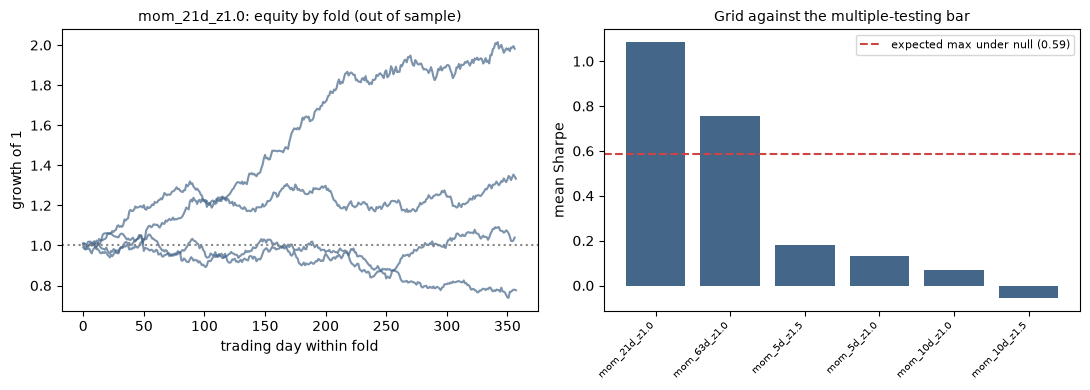

risk_report 9a5c6997


In [18]:
with store.create_node(step_type="risk_report", parent=validation_id) as node:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    for node_id in grid_v2:
        record = store.get(node_id)
        if record.metadata["config"]["value"] == best_config:
            curve = np.load(record / "equity_curve.npy")
            ax1.plot(curve, color="#468", alpha=0.7)
    ax1.axhline(1.0, color="#888", ls=":")
    ax1.set_title(f"{best_config}: equity by fold (out of sample)", fontsize=10)
    ax1.set_xlabel("trading day within fold")
    ax1.set_ylabel("growth of 1")

    ax2.bar(range(len(summary_v2)), summary_v2["sharpe"], color="#468")
    ax2.axhline(
        expected_max,
        color="#c44",
        ls="--",
        label=f"expected max under null ({expected_max:.2f})",
    )
    ax2.set_xticks(range(len(summary_v2)))
    ax2.set_xticklabels(summary_v2.index, rotation=45, ha="right", fontsize=7)
    ax2.set_ylabel("mean Sharpe")
    ax2.set_title("Grid against the multiple-testing bar", fontsize=10)
    ax2.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(node / "risk_report.png", dpi=110)
    plt.show()

    node.add_meta("strategy", best_config, group="Report")
    node.add_meta("holdout_sharpe", round(result["sharpe"], 4), group="Report")
    node.add_meta("cost_assumption_bps", COST_BPS, group="Report")
    node.add_meta(
        "capacity_note", "no market impact modelled", group="Report", searchable=False
    )
    node.add_meta("walkforward_sharpe", round(best_sharpe, 4), group="Report")
    node.add_meta("multiple_testing_bar", round(expected_max, 4), group="Report")
    node.add_meta("conclusion", "do not deploy", group="Report")
    node.add_meta(
        "rationale",
        "clears the multiple-testing bar in walk-forward but earns "
        "nothing in the held-out regime",
        group="Report",
        searchable=False,
    )
    node.add_meta("charts", node / "risk_report.png", group="Report", data_type="image")
    node.add_meta(
        "known_limitations",
        {
            "survivorship": "universe is fixed, no delistings",
            "impact": "linear costs only",
            "regime": "holdout is a single regime",
        },
        group="Report",
        data_type="json",
    )

report_id = node.node_id
print(f"risk_report {report_id}")

## 12. The audit questions

**What produced this number?** One call gives the whole chain from price data
to report.

In [19]:
for record in store.lineage(report_id)[:3]:
    print(f"  gen {record.generation}  {record.step_type:<12} {record.node_id}")
print(f"  ... {len(store.lineage(report_id)) - 5} backtest nodes ...")
for record in store.lineage(report_id)[-2:]:
    print(f"  gen {record.generation}  {record.step_type:<12} {record.node_id}")

  gen 0  market_data  c9067d15
  gen 1  feature_set  c110270a
  gen 1  backtest     3a7b067a
  ... 24 backtest nodes ...
  gen 1  validation   a93e86ad
  gen 1  risk_report  9a5c6997


**Was the signal lagged?** The single question that would have caught the bug,
answered against the feature set that actually fed the report.

In [20]:
feature_used = store.ancestors(report_id, step_type="feature_set")[0]
print(
    f"feature_set     {feature_used.node_id} (version "
    f"{feature_used.metadata['version']['value']})"
)
print(f"signal_lag_days {feature_used.metadata['signal_lag_days']['value']}")
print(f"definition      {feature_used.metadata['definition']['value']}")

feature_set     c110270a (version 2)
signal_lag_days 1
definition      z = (trailing_return - xs_mean) / xs_std; shifted 1d, traded next close


**Who ran it, on what code?** Recorded on every node without being asked.

In [21]:
for key, value in store.get(report_id).provenance.items():
    print(f"  {key:<16} {value}")

  user             js
  python_version   3.12.12
  platform         macOS-26.5.1-arm64-arm-64bit
  git_commit       c4088aa72d7cbc554f01467cd0ab06147535e4a2
  git_dirty        True
  git_branch       main


**Show me the whole grid as a table.** `sql()` is read-only over a documented
schema, so a reporting query cannot damage the research record.

In [22]:
rows = store.sql(
    """
    SELECT json_extract(c.value, '$')              AS config,
           count(*)                                AS folds,
           round(avg(CAST(s.value AS REAL)), 3)    AS mean_sharpe,
           round(min(CAST(d.value AS REAL)), 3)    AS worst_drawdown
    FROM metadata c
    JOIN metadata s ON s.node_id = c.node_id AND s.key = 'sharpe'
    JOIN metadata d ON d.node_id = c.node_id AND d.key = 'max_drawdown'
    JOIN node n     ON n.node_id = c.node_id
    WHERE c.key = 'config' AND n.step_type = 'backtest'
    GROUP BY config
    ORDER BY mean_sharpe DESC
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

      config  folds  mean_sharpe  worst_drawdown
mom_21d_z1.0      4        1.085          -0.304
mom_63d_z1.0      4        0.756          -0.200
 mom_5d_z1.5      4        0.182          -0.415
 mom_5d_z1.0      4        0.129          -0.185
mom_10d_z1.0      4        0.071          -0.365
mom_10d_z1.5      4       -0.055          -0.398


**Which strategies survived a drawdown limit?** A predicate receives the
stored value, or `None` when the node has no such key, so the guard is
required rather than defensive.

In [23]:
MANDATE = -0.20  # a 20% drawdown limit, the kind a risk committee sets

tolerable = store.find(
    step_type="backtest", max_drawdown=lambda d: d is not None and d > MANDATE
)
print(
    f"{len(tolerable)} of {len(trials)} backtest folds stayed inside "
    f"a {abs(MANDATE):.0%} drawdown limit"
)
worst = store.find(
    step_type="backtest", max_drawdown=lambda d: d is not None and d < -0.35
)
print("\nfolds that breached 35%:")
for record in worst[:4]:
    meta = record.metadata
    print(
        f"  {meta['config']['value']:<14} fold {meta['fold']['value']}  "
        f"drawdown {meta['max_drawdown']['value']:.2%}  "
        f"({meta['test_start']['value']} to {meta['test_end']['value']})"
    )

16 of 24 backtest folds stayed inside a 20% drawdown limit

folds that breached 35%:
  mom_5d_z1.5    fold 1  drawdown -41.46%  (2019-05-13 to 2020-09-23)
  mom_10d_z1.0   fold 3  drawdown -36.52%  (2022-02-07 to 2023-06-21)
  mom_10d_z1.5   fold 3  drawdown -39.79%  (2022-02-07 to 2023-06-21)


## 13. What this store did and did not buy

Worth being straight about, because it differs from the other examples.

In [24]:
final = store.stats()
print(f"  nodes            {final['nodes']}")
print(f"  artifacts        {final['artifacts']}")
print(f"  logical bytes    {final['logical_bytes'] / 1e6:.2f} MB")
print(f"  stored in pool   {final['chunk_stored_bytes'] / 1e6:.2f} MB")
print(f"  database on disk {final['database_bytes'] / 1e6:.2f} MB")
print(f"  dedup ratio      {final['dedup_ratio']}x")

  nodes            29
  artifacts        58
  logical bytes    1.47 MB
  stored in pool   1.20 MB
  database on disk 5.76 MB
  dedup ratio      1.219x


The deduplication ratio here is unremarkable, and it should be. The artifacts
are small equity curves and daily return vectors, not the near-identical
multi-megabyte fields of the optimisation example, so there is little for
chunk sharing to find. On a metadata-heavy research store the database is
mostly index, and `database_bytes` is dominated by the node and metadata rows
rather than the payload.

That is fine, because storage was never the reason to use it here. What this
store bought was:

- **A denominator.** The multiple-testing correction needed the number of
  configurations tried, and it was a query rather than a recollection.
- **A blast radius.** When the look-ahead bug surfaced, the set of invalid
  results was computed exactly, with the price data left untouched.
- **A withdrawal record.** The contaminated work was archived as JSON before
  being destroyed, so it can be shown without being trusted.
- **A selection context.** The chosen strategy is joined to every candidate it
  beat, not just reported on its own.
- **A negative result worth keeping.** The conclusion was "do not deploy", and
  it is stored with the evidence that produced it rather than lost when the
  researcher moved on.
- **`reuse_identical=False`.** Two identical runs stay two runs, which is the difference
  between a research log and an audit trail.

In [25]:
backup = store.backup(WORKDIR / "research_backup.db")
graph = store.generate_web_graph()
print(f"backup     {backup.name} ({backup.stat().st_size / 1e6:.1f} MB)")
print(f"web graph  {graph.name} ({graph.stat().st_size / 1024:.0f} KiB)")

backup     research_backup.db (1.6 MB)
web graph  interactive_pipeline.html (627 KiB)


In [26]:
store.host_live_graph()

Ancestree explorer running at: http://127.0.0.1:50828  (Store close will terminate background thread)


'http://127.0.0.1:50828'